In [58]:
import pm4py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import powerlaw

from inequality.gini import Gini
from statsmodels.stats.multitest import multipletests

In [59]:
# Load dataset
filepath = "generated/preprocessed_dataset.csv"
df = pd.read_csv(filepath, parse_dates=["time:timestamp"])

df["case:concept:name"] = df["case:concept:name"].astype(str)
df["time:timestamp"]= pd.to_datetime(df["time:timestamp"])

df.head()

,responsible_physician,disease,start_date,time:timestamp,concept:name,item,prescription_date,process_time,quantity,readmission_status,outlier_label,@@index,@@case_index,case:concept:name
0,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaN,0.0,0.0,Sem retorno,outlier,0,0,5446538
1,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaN,0.0,0.0,Sem retorno,outlier,1,0,5446538
2,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (...,2020-07-21 10:51:00+00:00,9.0,1.0,Sem retorno,outlier,2,0,5446538
3,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaN,0.0,0.0,Sem retorno,outlier,3,0,5446538
4,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaN,0.0,0.0,Sem retorno,outlier,4,0,5446538


In [60]:
# Incremental lead time between consecutive events in each case
df["event_lead_time_min"] = (
    df.groupby("case:concept:name")["time:timestamp"]
    .diff()
    .dt.total_seconds()
    .fillna(0)
)

# Convert event lead time to minutes (the time between start and current event in minutes)
df["event_lead_time_min"] = df["event_lead_time_min"] / 60

# Cumulative lead time from the start of the case to each event
df["cumulative_lead_time_min"] = (
    df.groupby("case:concept:name")["event_lead_time_min"].cumsum()
)

In [61]:
def compute_case_kpis(segment_df: pd.DataFrame):
    """
    Compute case KPIs: total case duration, case size and rework count.
    Rework is computed by counting repeated activities per case (counts > 1).
    Missing rework values are filled with 0.

    Parameters
    ----------
    segment_df : pd.DataFrame
        Event log dataframe 
    
    Returns
    -------
    pd.DataFrame
        DataFrame indexed by `case:concept:name` with columns:
        - duration_min: max cumulative_lead_time_min per case
        - case_size: number of events per case
        - rework_count: sum of repeated activity counts per case (0 if none)
    """
    
    # Case Duration (total case duration = max cumulative_lead_time_min per case)
    duration = (
        segment_df.groupby("case:concept:name")["cumulative_lead_time_min"]
        .max()
        .rename("duration_min")
    )

    # Case Size (number of events per case)
    size = (
        segment_df.groupby("case:concept:name")["concept:name"]
        .count()
        .rename("case_size")
    )
    
    # Rework Count (sum of repeated activity counts per case)
    rework = (
        segment_df.groupby(["case:concept:name", "concept:name"])
        .size()
        .reset_index(name="count")
        .query("count > 1")
        .assign(rework_count=lambda x: x["count"] - 1)
        .groupby("case:concept:name")["rework_count"]
        .sum()
        .rename("rework_count")
    )

    kpis = pd.concat([duration, size, rework], axis=1).fillna(0)
    return kpis

### Variant Distribution Analysis

In [62]:
variants_dict = pm4py.get_variants(df)

# Compute frequencies
variants_df = pd.DataFrame(list(variants_dict.items()), columns=["variant", "frequency"])
variants_df["percentage"] = 100 * variants_df["frequency"] / variants_df["frequency"].sum()

# Sort by frequency
variants_df = variants_df.sort_values("frequency", ascending=False).reset_index(drop=True)

# Compute variant length
variants_df["variant_length"] = [len(variant) for variant in variants_df["variant"]]

# Create a variable for the distribution 
distribution = variants_df["frequency"]

total_cases = sum(distribution)
cumulative_coverage = np.cumsum(distribution) / total_cases

print(f"Total number of cases: {total_cases}")
print(f"Number of unique variants: {len(variants_df)}")
print(f"Top 10 variants cover: {variants_df["percentage"].head(10).sum():.2f}% of traces")

# Find the index where coverage >= 80%
k_80 = np.argmax(cumulative_coverage >= 0.80) + 1  # +1 for 1-based indexing
print(f"Top {k_80} variants ({(k_80 / len(variants_df)) * 100:.2f}% of total) cover 80% of cases (empirical)")

# Find the index where coverage >= 90%
k_90 = np.argmax(cumulative_coverage >= 0.90) + 1  # +1 for 1-based indexing
print(f"Top {k_90} variants ({(k_90 / len(variants_df)) * 100:.2f}% of total) cover 90% of cases (empirical)")

variants_df

Total number of cases: 436
Number of unique variants: 103
Top 10 variants cover: 76.83% of traces
Top 17 variants (16.50% of total) cover 80% of cases (empirical)
Top 60 variants (58.25% of total) cover 90% of cases (empirical)


,variant,frequency,percentage,variant_length
0,"(Atendimento, Triagem, Consulta, Alta)",247,56.651376,4
1,"(Atendimento, Triagem, Consulta, Exames de Ima...",49,11.238532,5
2,"(Atendimento, Triagem, Consulta, Exames Labora...",12,2.752294,5
3,"(Atendimento, Triagem, Consulta, Exames Labora...",8,1.834862,7
4,"(Atendimento, Triagem, Consulta, Exames Labora...",4,0.917431,6
...,...,...,...,...
98,"(Atendimento, Triagem, Consulta, Materiais Hos...",1,0.229358,16
99,"(Atendimento, Triagem, Consulta, Exames Labora...",1,0.229358,9
100,"(Atendimento, Consulta, Triagem, Materiais Hos...",1,0.229358,10
101,"(Atendimento, Consulta, Medicamentos, Exames L...",1,0.229358,5


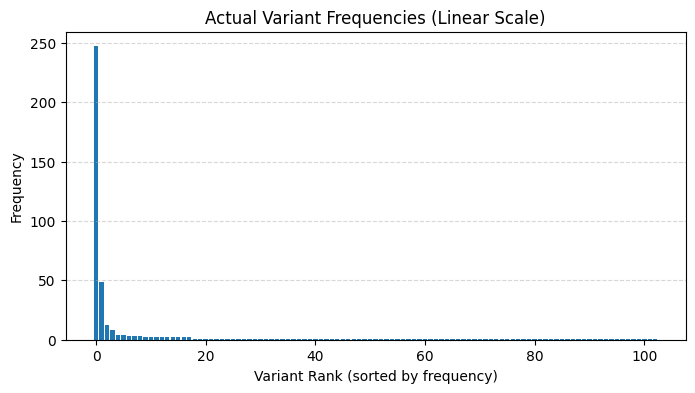

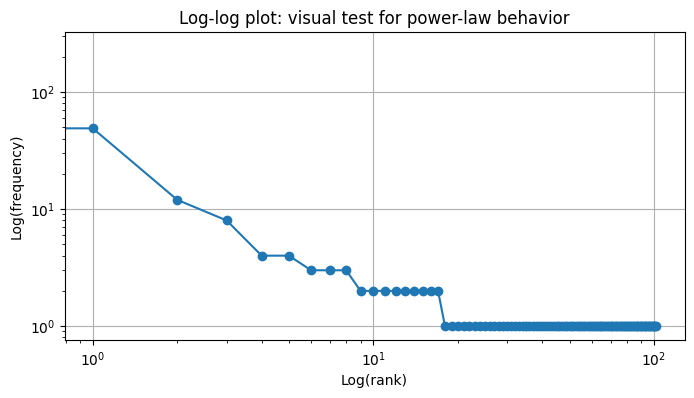

In [63]:
# Plot the distribution of variant frequencies
plt.figure(figsize=(8, 4))
plt.bar(range(0, len(distribution)), distribution)
plt.title("Actual Variant Frequencies (Linear Scale)")
plt.xlabel("Variant Rank (sorted by frequency)")
plt.ylabel("Frequency")
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.show()

# Log-log plot to visually assess power-law behavior
plt.figure(figsize=(8, 4))
plt.loglog(range(0, len(distribution)), distribution, marker='o', linestyle='solid')
plt.xlabel('Log(rank)')
plt.ylabel('Log(frequency)')
plt.title('Log-log plot: visual test for power-law behavior')
plt.grid(True)
plt.show()

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 6/6 [00:00<00:00, 1581.86it/s]

--- Power Law Fit Results ---
Alpha (α): 2.604
x_min: 1.0
KS Distance (D): 0.058
Power Law vs Lognormal: R = -6.854, p = 0.251
No significant difference between power law and lognormal fits, both models explain the data equally well.



c:\Users\milan\AppData\Local\Programs\Python\Python313\Lib\site-packages\powerlaw\distributions.py:2792: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm


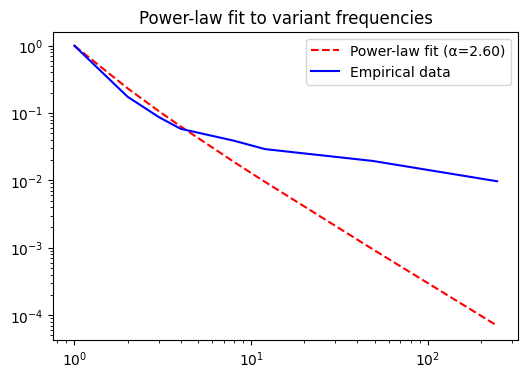

In [64]:
# Fit power law and compare to lognormal  
fit = powerlaw.Fit(distribution, discrete=True)  
R, p = fit.distribution_compare('power_law', 'lognormal')  

# Print results  
print("--- Power Law Fit Results ---")  
print(f"Alpha (α): {fit.power_law.alpha:.3f}")  
print(f"x_min: {fit.power_law.xmin}")  
print(f"KS Distance (D): {fit.power_law.D:.3f}")  
print(f"Power Law vs Lognormal: R = {R:.3f}, p = {p:.3f}")  

if p < 0.05:
    if R > 0:  
        print("Power law is a better fit than lognormal.")  
    else:  
        print("Lognormal may be a better fit.")  
else:
    print("No significant difference between power law and lognormal fits, both models explain the data equally well.")



# Plot fit for comparison
plt.figure(figsize=(6,4))
fit.power_law.plot_ccdf(color='r', linestyle='--', label=f'Power-law fit (α={fit.power_law.alpha:.2f})') # Theoretical PDF (from fitted α)
fit.plot_ccdf(color='b', label='Empirical data') # Empirical density (from  data)
plt.legend()
plt.title('Power-law fit to variant frequencies')
plt.show()

Total number of cases after cutoff: 351
Percentage of cases over cutoff variant frequency: 80.50%
Number of unique variants after cutoff: 18


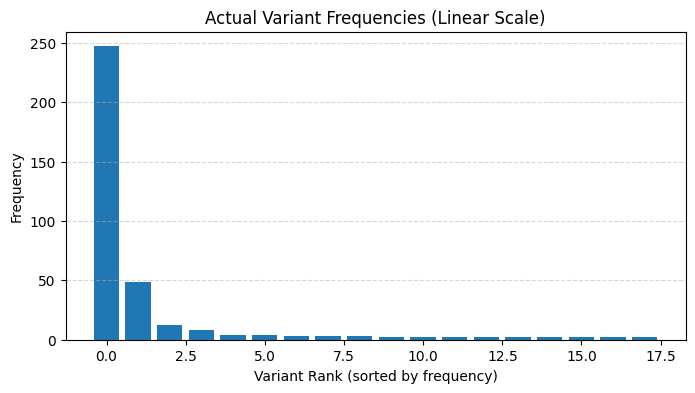

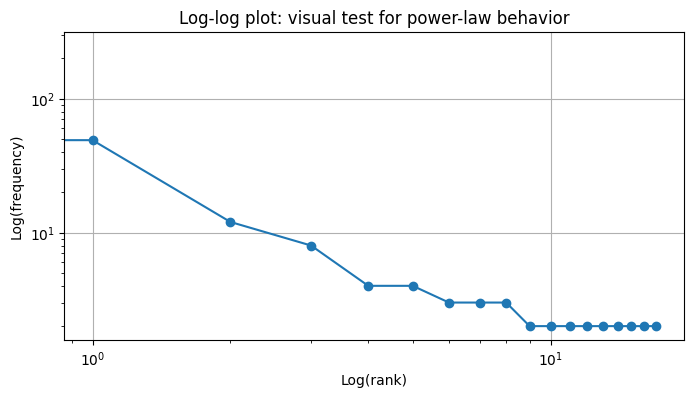

In [65]:
variant_cutoff = variants_df[variants_df["frequency"] > fit.power_law.xmin]

distribution_cutoff = variant_cutoff["frequency"]

total_cases_cutoff = sum(distribution_cutoff)

print(f"Total number of cases after cutoff: {total_cases_cutoff}")
print(f"Percentage of cases over cutoff variant frequency: {total_cases_cutoff / total_cases * 100:.2f}%")
print(f"Number of unique variants after cutoff: {len(variant_cutoff)}")

# Plot the distribution of variant frequencies
plt.figure(figsize=(8, 4))
plt.bar(range(0, len(distribution_cutoff)), distribution_cutoff)
plt.title("Actual Variant Frequencies (Linear Scale)")
plt.xlabel("Variant Rank (sorted by frequency)")
plt.ylabel("Frequency")
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.show()

# Log-log plot to visually assess power-law behavior
plt.figure(figsize=(8, 4))
plt.loglog(range(0, len(distribution_cutoff)), distribution_cutoff, marker='o', linestyle='solid')
plt.xlabel('Log(rank)')
plt.ylabel('Log(frequency)')
plt.title('Log-log plot: visual test for power-law behavior')
plt.grid(True)
plt.show()

In [66]:
# Compute per-case variant tuples
case_variants = df.groupby("case:concept:name")["concept:name"].apply(lambda x: tuple(x.tolist()))

# Identify cases that belong to variants above the power-law cutoff
cutoff_variant_set = set(variant_cutoff["variant"])
cases_over_cutoff = case_variants[case_variants.isin(cutoff_variant_set)].index

# Filter events for cutoff cases
df_cutoff = df[df["case:concept:name"].isin(cases_over_cutoff)]

# Compute activity frequencies overall and for cutoff cases
total_activity_counts = df["concept:name"].value_counts().rename("total_count")
cutoff_activity_counts = df_cutoff["concept:name"].value_counts().rename("cutoff_count")

# Combine and show percentages
activity_freqs = pd.concat([total_activity_counts, cutoff_activity_counts], axis=1).fillna(0)
activity_freqs["cutoff_pct_of_total"] = activity_freqs["cutoff_count"] / activity_freqs["total_count"] * 100
activity_freqs = activity_freqs.sort_values("total_count", ascending=False)

activity_freqs

,total_count,cutoff_count,cutoff_pct_of_total
concept:name,,,
Medicamentos,465,73.0,15.698925
Atendimento,436,351.0,80.504587
Alta,436,351.0,80.504587
Consulta,435,351.0,80.689655
Triagem,419,343.0,81.861575
Materiais Hospitalares,415,52.0,12.530120
Exames Laboratoriais,188,47.0,25.000000
Exames de Imagem,120,67.0,55.833333
Exames Eletrofisiológicos,19,0.0,0.000000


In [67]:
# Discover the most reworked activity in the log
rework_counts = pm4py.get_rework_cases_per_activity(df)

rework_counts

{'Exames Eletrofisiológicos': 3,
 'Exames Laboratoriais': 35,
 'Exames de Imagem': 8,
 'Materiais Hospitalares': 80,
 'Medicamentos': 84}

In [68]:
# Per-case outlier/inlier counts overall
case_labels = df.groupby("case:concept:name")["outlier_label"].first()
counts_overall = case_labels.value_counts()
pct_overall = counts_overall / total_cases * 100

print("Overall cases:")
for label, cnt in counts_overall.items():
    print(f"{label}: {cnt} ({pct_overall[label]:.2f}%)")

# Per-case outlier/inlier counts after cutoff
case_labels_cutoff = df_cutoff.groupby("case:concept:name")["outlier_label"].first()
counts_cutoff = case_labels_cutoff.value_counts()
pct_cutoff = counts_cutoff / total_cases_cutoff * 100

print("\nAfter cutoff cases:")
for label, cnt in counts_cutoff.items():
    print(f"{label}: {cnt} ({pct_cutoff[label]:.2f}%)")

Overall cases:
inlier: 409 (93.81%)
outlier: 27 (6.19%)

After cutoff cases:
inlier: 340 (96.87%)
outlier: 11 (3.13%)


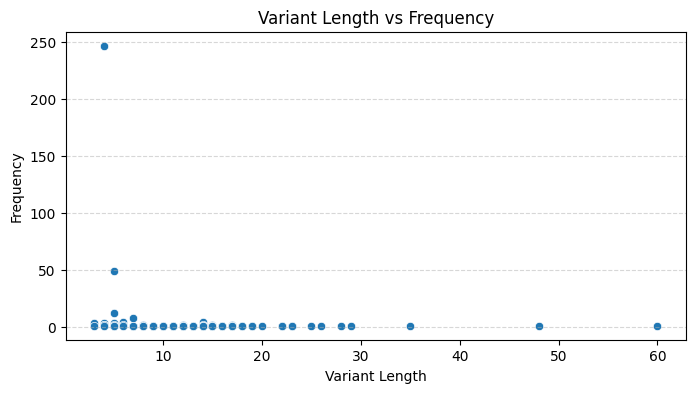

In [69]:
# Plot variant length vs frequency
plt.figure(figsize=(8,4))
sns.scatterplot(data=variants_df, x="variant_length", y="frequency")
plt.title("Variant Length vs Frequency")
plt.xlabel("Variant Length")
plt.ylabel("Frequency")
plt.grid(True, axis="y", ls="--", alpha=0.5)
plt.show()

In [70]:
# Since frequency is non-normal, use Spearman's correlation to test the correlation between variant length and frequency
corr, p_val = stats.spearmanr(variants_df["variant_length"], variants_df["frequency"])
print(f"Spearman correlation coefficient: {corr:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ There is a statistically significant correlation between variant length and frequency.")
else:
    print("\n❌ There is NOT statistically significant correlation between variant length and frequency.")

Spearman correlation coefficient: -0.4423
P-value: 2.9040e-06

✅ There is a statistically significant correlation between variant length and frequency.


In [71]:
# Top-3 variant KPI analysis using compute_case_kpis
top_variants = variants_df.head(3)["variant"].tolist()

res = []
for variant in top_variants:
    cases = case_variants[case_variants == variant].index
    seg_df = df[df["case:concept:name"].isin(cases)]
    kpis = compute_case_kpis(seg_df)
    res.append({
        "variant": variant,
        "frequency": len(cases),
        "lenght": len(variant),
        "mean_duration_min": kpis["duration_min"].mean(),
        "median_duration_min": kpis["duration_min"].median(),
        "mean_case_size": kpis["case_size"].mean(),
        "median_case_size": kpis["case_size"].median(),
    })

top_variant_kpis = pd.DataFrame(res).set_index("variant")

top_variant_kpis

,frequency,lenght,mean_duration_min,median_duration_min,mean_case_size,median_case_size
variant,,,,,,
"(Atendimento, Triagem, Consulta, Alta)",247,4,78.000000,57.0,4.0,4.0
"(Atendimento, Triagem, Consulta, Exames de Imagem, Alta)",49,5,122.510204,101.0,5.0,5.0
"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Alta)",12,5,87.916667,79.5,5.0,5.0


In [72]:
# Map cases to their variants and outlier labels
variant_case_map = case_variants.reset_index()
variant_case_map.columns = ["case:concept:name", "variant"]

outlier_map = df.groupby("case:concept:name")["outlier_label"].first().reset_index()
merged = variant_case_map.merge(outlier_map, on="case:concept:name")

# Compute outlier frequency and percentage per variant
outlier_counts_by_variant = (
    merged.assign(is_outlier=merged["outlier_label"] == "outlier")
    .groupby("variant")["is_outlier"]
    .sum()
    .rename("outlier_count")
)

variant_outlier_table = variants_df.set_index("variant").join(outlier_counts_by_variant).fillna(0)
variant_outlier_table["outlier_percentage"] = variant_outlier_table["outlier_count"] / variant_outlier_table["frequency"] * 100

# Sort by frequency
variant_outlier_table = variant_outlier_table.sort_values("frequency", ascending=False)

variant_outlier_table

,frequency,percentage,variant_length,outlier_count,outlier_percentage
variant,,,,,
"(Atendimento, Triagem, Consulta, Alta)",247,56.651376,4,4,1.619433
"(Atendimento, Triagem, Consulta, Exames de Imagem, Alta)",49,11.238532,5,2,4.081633
"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Alta)",12,2.752294,5,0,0.000000
"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Exames Laboratoriais, Exames de Imagem, Alta)",8,1.834862,7,2,25.000000
"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Exames de Imagem, Alta)",4,0.917431,6,0,0.000000
...,...,...,...,...,...
"(Atendimento, Triagem, Consulta, Materiais Hospitalares, Materiais Hospitalares, Materiais Hospitalares, Materiais Hospitalares, Medicamentos, Medicamentos, Medicamentos, Medicamentos, Exames Laboratoriais, Exames Laboratoriais, Exames Laboratoriais, Exames de Imagem, Alta)",1,0.229358,16,0,0.000000
"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Exames Laboratoriais, Exames Laboratoriais, Exames Laboratoriais, Exames de Imagem, Alta)",1,0.229358,9,0,0.000000
"(Atendimento, Consulta, Triagem, Materiais Hospitalares, Materiais Hospitalares, Medicamentos, Medicamentos, Materiais Hospitalares, Materiais Hospitalares, Alta)",1,0.229358,10,0,0.000000


In [73]:
merged["variant_hash"] = merged["variant"].apply(lambda x: hash(x))

ct = pd.crosstab(merged["variant_hash"], merged["outlier_label"])
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"Chi-squared test results: chi2={chi2}, p-value={p}, dof={dof}")

if p < 0.05:
    print("✅ There is a statistically significant association between variant and outlier status.")
else:
    print("❌ There is NOT a statistically significant association between variant and outlier status.")

Chi-squared test results: chi2=283.5928598883909, p-value=5.071475729594005e-19, dof=102
✅ There is a statistically significant association between variant and outlier status.


Conclusion:
- About 16% of the variants cover 80% of the variants.
- The process variants distribution, which has a very long tail, don't follow a power law distribution. There are a lot of unique variant that occur only once.
- Variant length and frequency are negatively correlated with a correlation coefficient of -0.4423. The longer a variant is, the less frequent it is.
- There is a significant association between variant and outlier status. This indicates that inefficiencies are not random but linked to specific execution paths of the process.
- Analyzing the KPIs of the top three options, the basic option (which ends directly with discharge) has a median duration of just 57 minutes. The second option, which includes imaging tests, nearly doubles the median to 101 minutes. Waiting for or performing diagnostic imaging is a clear structural bottleneck.
- `Materiais Hospitalares` (80) and `Medicamentos` (84) are the most reworked activity in the log.

### Case size and case time correlation

In [74]:
kpis_all = compute_case_kpis(df)

display(kpis_all.describe())

,duration_min,case_size,rework_count
count,436.000000,436.000000,436.000000
mean,132.616972,6.727064,1.901376
std,197.285166,5.816844,4.884119
min,8.000000,3.000000,0.000000
25%,46.750000,4.000000,0.000000
50%,82.000000,4.000000,0.000000
75%,159.250000,5.250000,0.000000
max,3221.000000,60.000000,52.000000


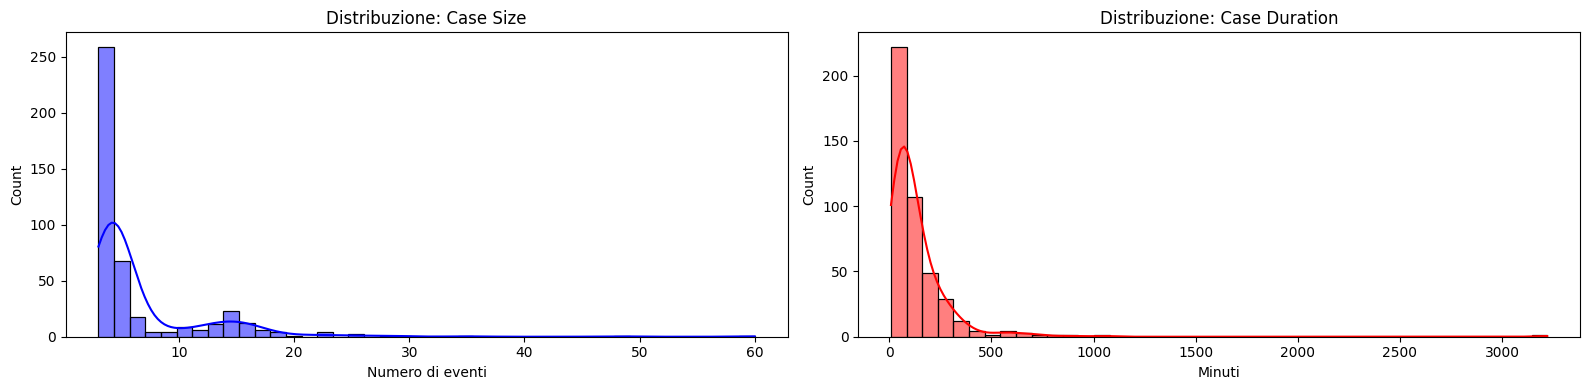

In [75]:
# Plot of case size and duration distributions 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.histplot(kpis_all["case_size"], kde=True, ax=axes[0], color='blue')
axes[0].set_title("Distribuzione: Case Size")
axes[0].set_xlabel("Numero di eventi")

sns.histplot(kpis_all["duration_min"], kde=True, ax=axes[1], color='red')
axes[1].set_title("Distribuzione: Case Duration")
axes[1].set_xlabel("Minuti")

plt.tight_layout()
plt.show()

In [76]:
# Test normality of case size and duration with Shapiro-Wilk test
_, p_size = stats.shapiro(kpis_all["case_size"])
_, p_duration = stats.shapiro(kpis_all["duration_min"])

print(f"Case Size - Shapiro p-value: {p_size:.4e} -> {'Normal' if p_size > 0.05 else 'Non-normal'}")
print(f"Case Duration - Shapiro p-value: {p_duration:.4e} -> {'Normal' if p_duration > 0.05 else 'Non-normal'}")

Case Size - Shapiro p-value: 2.2947e-32 -> Non-normal
Case Duration - Shapiro p-value: 7.9718e-35 -> Non-normal


In [77]:
# Since both distributions are non-normal, use Spearman's correlation to test the correlation between case size and duration
corr, p_val = stats.spearmanr(kpis_all["case_size"], kpis_all["duration_min"])

print(f"=== Correlation between case size and duration (Spearman) ===")
print(f"Spearman correlation coefficient: {corr:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ There is a statistically significant correlation between case size and case duration.")
else:
    print("\n❌ There is NOT statistically significant correlation between case size and case duration.")

=== Correlation between case size and duration (Spearman) ===
Spearman correlation coefficient: 0.5901
P-value: 2.9046e-42

✅ There is a statistically significant correlation between case size and case duration.


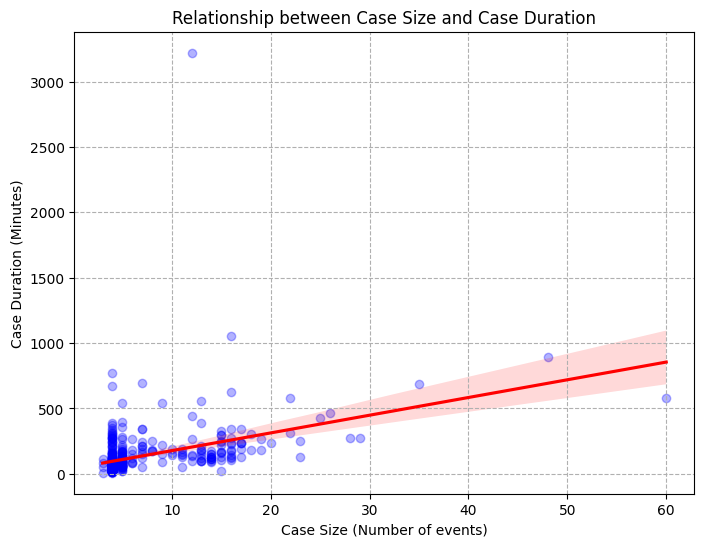

In [78]:
# Scatter plot with linear regression line to visualize the relationship between case size and duration
plt.figure(figsize=(8, 6))

sns.regplot(
    x=kpis_all["case_size"], 
    y=kpis_all["duration_min"], 
    scatter_kws={'alpha': 0.3, 'color': 'blue'}, 
    line_kws={'color': 'red'}
)
plt.title("Relationship between Case Size and Case Duration")
plt.xlabel("Case Size (Number of events)")
plt.ylabel("Case Duration (Minutes)")
plt.grid(linestyle='--')
plt.show()

Conclusion: there is a significant correlation between case size and case duration. We have a correlation coefficient of 0.5901 (> 0), so when case size increase, also case duration increase too.

### Outlier segmentation analysis

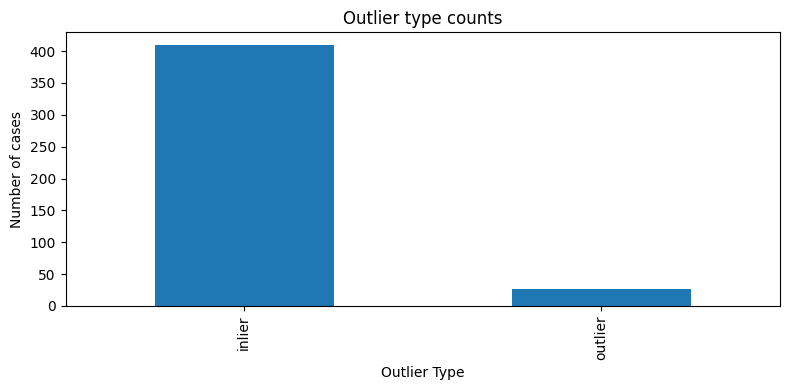

In [79]:
# Outlier frequency
outlier_counts = df.groupby("case:concept:name")["outlier_label"].first().value_counts()

ax = outlier_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Outlier type counts")
ax.set_xlabel("Outlier Type")
ax.set_ylabel("Number of cases")

plt.tight_layout()
plt.show()

In [80]:
# Segment by outlier type
outliers = df[df["outlier_label"] == "outlier"]
inliers = df[df["outlier_label"] != "outlier"]

print(f"Number of outlier cases: {outliers['case:concept:name'].nunique()}")
print(f"Number of inlier cases: {inliers['case:concept:name'].nunique()}")

Number of outlier cases: 27
Number of inlier cases: 409


In [81]:
# Compute KPIs for each segment
kpi_inlier = compute_case_kpis(inliers)
print(f"\nInliers")
display(kpi_inlier.describe())

kpi_outlier = compute_case_kpis(outliers)
print(f"Outliers")
display(kpi_outlier.describe())


Inliers


,duration_min,case_size,rework_count
count,409.000000,409.000000,409.000000
mean,100.506112,6.193154,1.452323
std,73.370538,4.362760,3.379335
min,8.000000,3.000000,0.000000
25%,44.000000,4.000000,0.000000
50%,78.000000,4.000000,0.000000
75%,136.000000,5.000000,0.000000
max,324.000000,29.000000,22.000000


Outliers


,duration_min,case_size,rework_count
count,27.000000,27.000000,27.000000
mean,619.037037,14.814815,8.703704
std,552.073747,13.964342,12.987612
min,334.000000,4.000000,0.000000
25%,364.000000,5.000000,0.000000
50%,465.000000,12.000000,6.000000
75%,646.500000,16.500000,10.500000
max,3221.000000,60.000000,52.000000


C:\Users\milan\AppData\Local\Temp\ipykernel_19984\2006175168.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='outlier_label', y='duration_min', ax=ax2, palette='Set2', cut=0)
C:\Users\milan\AppData\Local\Temp\ipykernel_19984\2006175168.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='outlier_label', y='case_size', ax=ax4, palette='Set2', cut=0)
C:\Users\milan\AppData\Local\Temp\ipykernel_19984\2006175168.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='

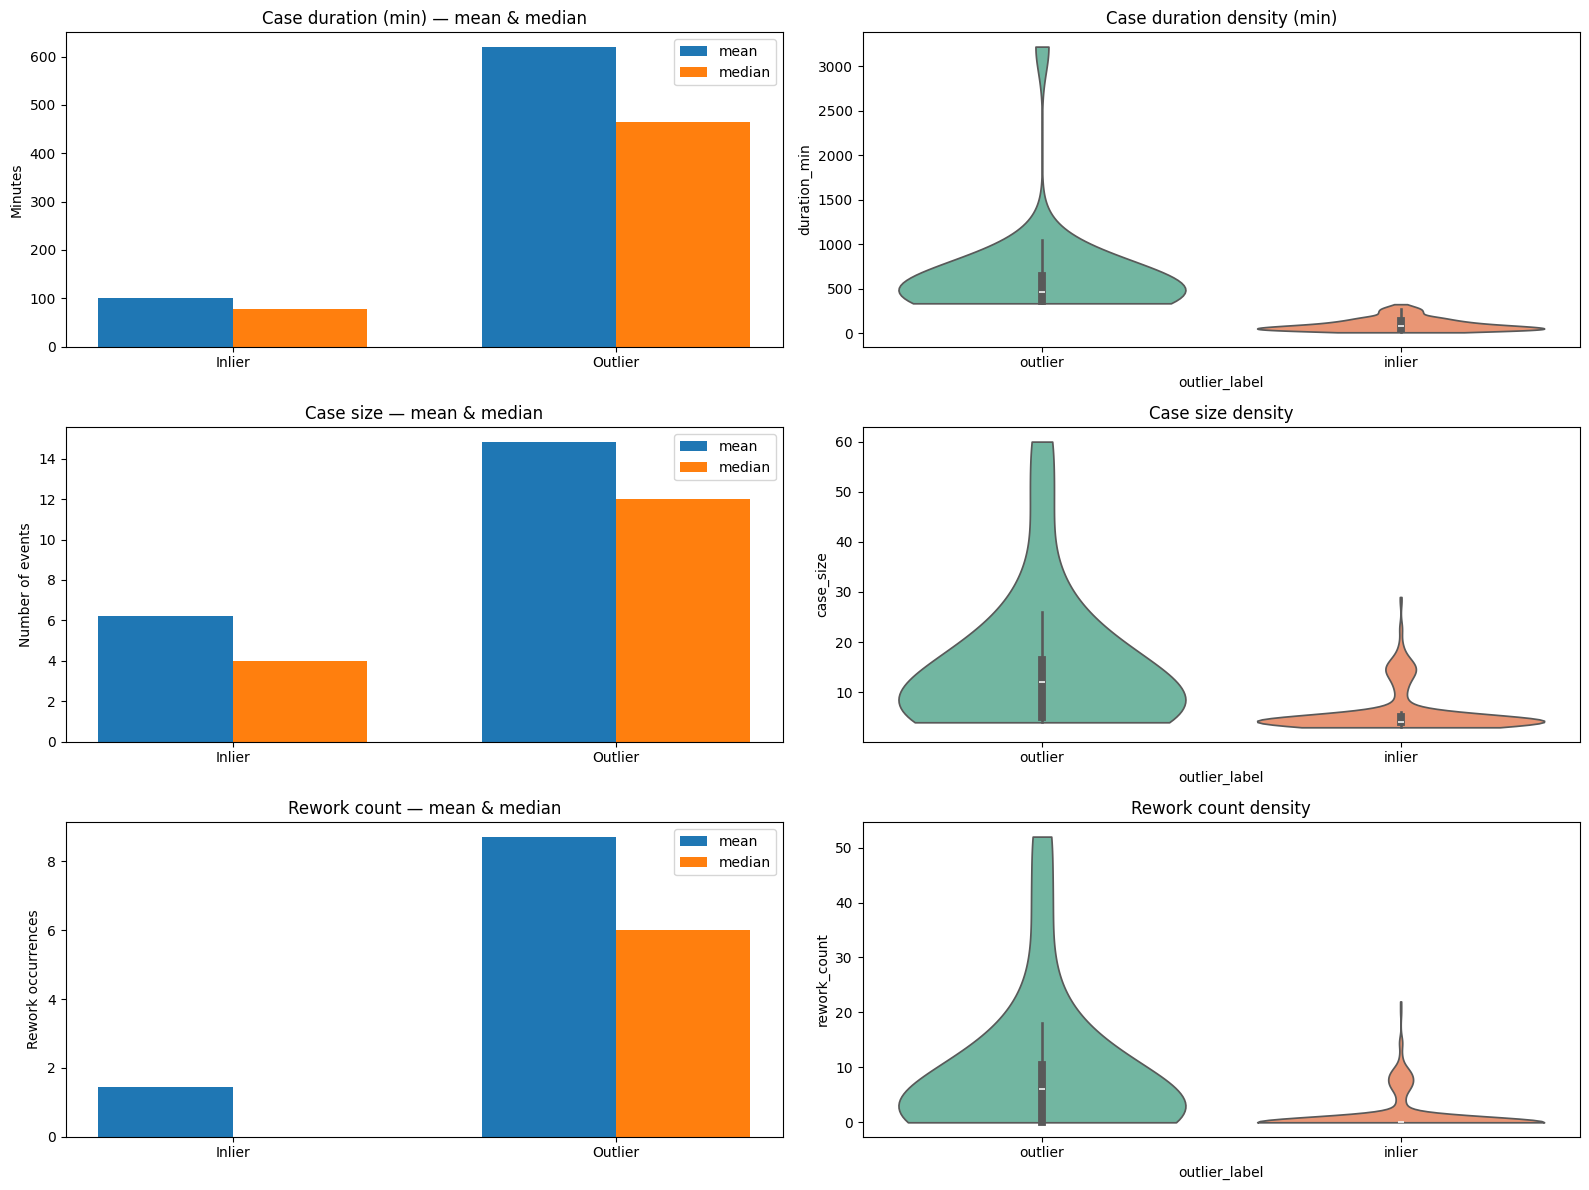

In [82]:
# Plot mean, median and density for duration, case size and rework per readmission segment
dur_mean = [kpi_inlier["duration_min"].mean(), kpi_outlier["duration_min"].mean()]
dur_med = [kpi_inlier["duration_min"].median(), kpi_outlier["duration_min"].median()]

size_mean = [kpi_inlier["case_size"].mean(), kpi_outlier["case_size"].mean()]
size_med = [kpi_inlier["case_size"].median(), kpi_outlier["case_size"].median()]

rework_mean = [kpi_inlier["rework_count"].mean(), kpi_outlier["rework_count"].mean()]
rework_med = [kpi_inlier["rework_count"].median(), kpi_outlier["rework_count"].median()]

kpi_inlier_plot = kpi_inlier.copy()
kpi_inlier_plot['outlier_label'] = 'inlier'

kpi_outlier_plot = kpi_outlier.copy()
kpi_outlier_plot['outlier_label'] = 'outlier'

combined_kpis = pd.concat([kpi_outlier_plot, kpi_inlier_plot])

labels = ["Inlier", "Outlier"]
x = [0, 1]
width = 0.35

fig, axs = plt.subplots(3, 2, figsize=(16, 12))

# Duration mean/median (left) and violin (right)
ax1 = axs[0,0]
ax2 = axs[0,1]
ax1.bar([xi - width / 2 for xi in x], dur_mean, width, label="mean")
ax1.bar([xi + width / 2 for xi in x], dur_med, width, label="median")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Case duration (min) — mean & median")
ax1.set_ylabel("Minutes")
ax1.legend()
sns.violinplot(data=combined_kpis, x='outlier_label', y='duration_min', ax=ax2, palette='Set2', cut=0)
ax2.set_title("Case duration density (min)")

# Case size mean/median (left) and violin (right)
ax3 = axs[1,0]
ax4 = axs[1,1]
ax3.bar([xi - width / 2 for xi in x], size_mean, width, label="mean")
ax3.bar([xi + width / 2 for xi in x], size_med, width, label="median")
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_title("Case size — mean & median")
ax3.set_ylabel("Number of events")
ax3.legend()
sns.violinplot(data=combined_kpis, x='outlier_label', y='case_size', ax=ax4, palette='Set2', cut=0)
ax4.set_title("Case size density")

# Rework mean/median (left) and violin (right)
ax5 = axs[2,0]
ax6 = axs[2,1]
ax5.bar([xi - width / 2 for xi in x], rework_mean, width, label="mean")
ax5.bar([xi + width / 2 for xi in x], rework_med, width, label="median")
ax5.set_xticks(x)
ax5.set_xticklabels(labels)
ax5.set_title("Rework count — mean & median")
ax5.set_ylabel("Rework occurrences")
ax5.legend()
sns.violinplot(data=combined_kpis, x='outlier_label', y='rework_count', ax=ax6, palette='Set2', cut=0)
ax6.set_title("Rework count density")

plt.tight_layout()
plt.show()

In [83]:
# Test KPIs between segments by Retorno (discharge)
print("=== Statistical analysis between outlier and inlier cases ===\n")

kpis_to_test = ["duration_min", "case_size", "rework_count"]
for kpi in kpis_to_test:
    data_outlier = kpi_outlier[kpi].dropna()
    data_inlier = kpi_inlier[kpi].dropna()

    print(f"--- KPI: {kpi} (Sample sizes: outlier={len(data_outlier)}, inlier={len(data_inlier)}) ---")
    
    # Normality test (Shapiro-Wilk)
    _, p_shapiro_outlier = stats.shapiro(data_outlier)
    _, p_shapiro_inlier = stats.shapiro(data_inlier)
    
    is_normal_outlier = p_shapiro_outlier > 0.05
    is_normal_inlier = p_shapiro_inlier > 0.05
    
    print(f"Normality of segment outlier (Shapiro p-value): {p_shapiro_outlier:.4f} -> {'Normal' if is_normal_outlier else 'Non-normal'}")
    print(f"Normality of segment inlier (Shapiro p-value): {p_shapiro_inlier:.4f} -> {'Normal' if is_normal_inlier else 'Non-normal'}")
    
    # Select test based on normality
    if is_normal_outlier and is_normal_inlier:
        print("Each sample are normal, we use T-test.")
        # equal_var=False applies Welch's t-test, which is more robust when variances are unequal
        res_test = stats.ttest_ind(data_outlier, data_inlier, equal_var=False) 
        test_name = "T-test"
    else:
        print("At least one sample is not normal. Performing Mann-Whitney U test.")
        res_test = stats.mannwhitneyu(data_outlier, data_inlier, alternative='two-sided')
        test_name = "Mann-Whitney U"

    p_val = float(res_test.pvalue)

    print(f"Risultato {test_name} p-value: {p_val:.4f}")
    if p_val < 0.05:
        print(f"✅ There is a statistically significant difference between outlier and inlier cases for '{kpi}'.\n")
    else:
        print(f"❌ There is NOT a statistically significant difference between outlier and inlier cases for '{kpi}'.\n")

=== Statistical analysis between outlier and inlier cases ===

--- KPI: duration_min (Sample sizes: outlier=27, inlier=409) ---
Normality of segment outlier (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment inlier (Shapiro p-value): 0.0000 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0000
✅ There is a statistically significant difference between outlier and inlier cases for 'duration_min'.

--- KPI: case_size (Sample sizes: outlier=27, inlier=409) ---
Normality of segment outlier (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment inlier (Shapiro p-value): 0.0000 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0000
✅ There is a statistically significant difference between outlier and inlier cases for 'case_size'.

--- KPI: rework_count (Sample sizes: outlier=27, inlier=409) ---
Normality of segment outlier (Shapiro p-value): 0.

Conclusion: There are a significant difference for case duration, case size and rework activity between `outlier` and `inlier` segment.
- case duration:    inlier[avg: 100.506112, median: 78.000000] outlier[avg: 619.037037, 465.000000]
- case size:        inlier[avg: 6.193154, median: 4.000000] outlier[avg: 14.814815, 12.000000]
- rework:           inlier[avg: 1.452323, median: 0.000000] outlier[avg: 8.703704, 6.000000]
 
As we can see, the most important problem in outlier are the rework activities, as the avg on inlier are 1.45 and the avg on outlier are close to 9. The more rework activity, the more case size, the more case duration.

### Readmission status segmentation analysis

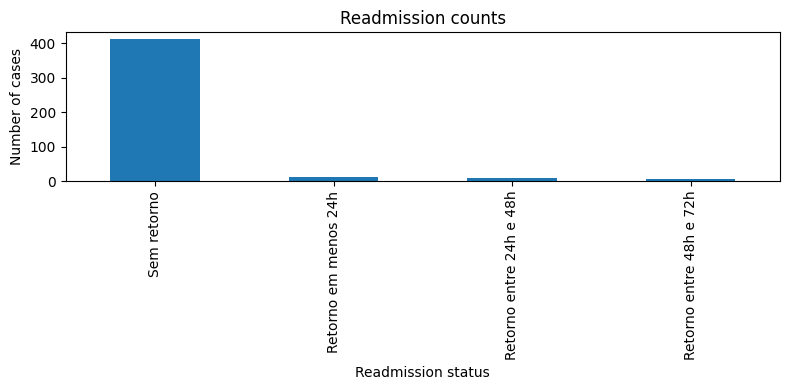

In [84]:
# Readmission frequency
readmission_counts = df.groupby("case:concept:name")["readmission_status"].first().value_counts()

ax = readmission_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Readmission counts")
ax.set_xlabel("Readmission status")
ax.set_ylabel("Number of cases")

plt.tight_layout()
plt.show()

In [85]:
# Segment by readmission status
discharged = df[df["readmission_status"] == "Sem retorno"] # cases discharged 
readmitted = df[df["readmission_status"] != "Sem retorno"] # cases readmitted

In [86]:
# Compute KPIs for each segment
kpi_discharged = compute_case_kpis(discharged)
print(f"Discharged")
display(kpi_discharged.describe())

kpi_readmitted = compute_case_kpis(readmitted)
print(f"\nReadmitted")
display(kpi_readmitted.describe())

Discharged


,duration_min,case_size,rework_count
count,411.000000,411.000000,411.000000
mean,129.394161,6.564477,1.788321
std,199.302847,5.766819,4.852604
min,8.000000,3.000000,0.000000
25%,45.000000,4.000000,0.000000
50%,80.000000,4.000000,0.000000
75%,150.500000,5.000000,0.000000
max,3221.000000,60.000000,52.000000



Readmitted


,duration_min,case_size,rework_count
count,25.000000,25.000000,25.000000
mean,185.600000,9.400000,3.760000
std,154.179279,6.103278,5.125752
min,35.000000,4.000000,0.000000
25%,93.000000,5.000000,0.000000
50%,155.000000,7.000000,1.000000
75%,245.000000,14.000000,7.000000
max,773.000000,28.000000,20.000000


C:\Users\milan\AppData\Local\Temp\ipykernel_19984\3079709915.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='Readmission status', y='duration_min', ax=ax3, palette='Set2', cut=0)
C:\Users\milan\AppData\Local\Temp\ipykernel_19984\3079709915.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='Readmission status', y='case_size', ax=ax4, palette='Set2', cut=0)


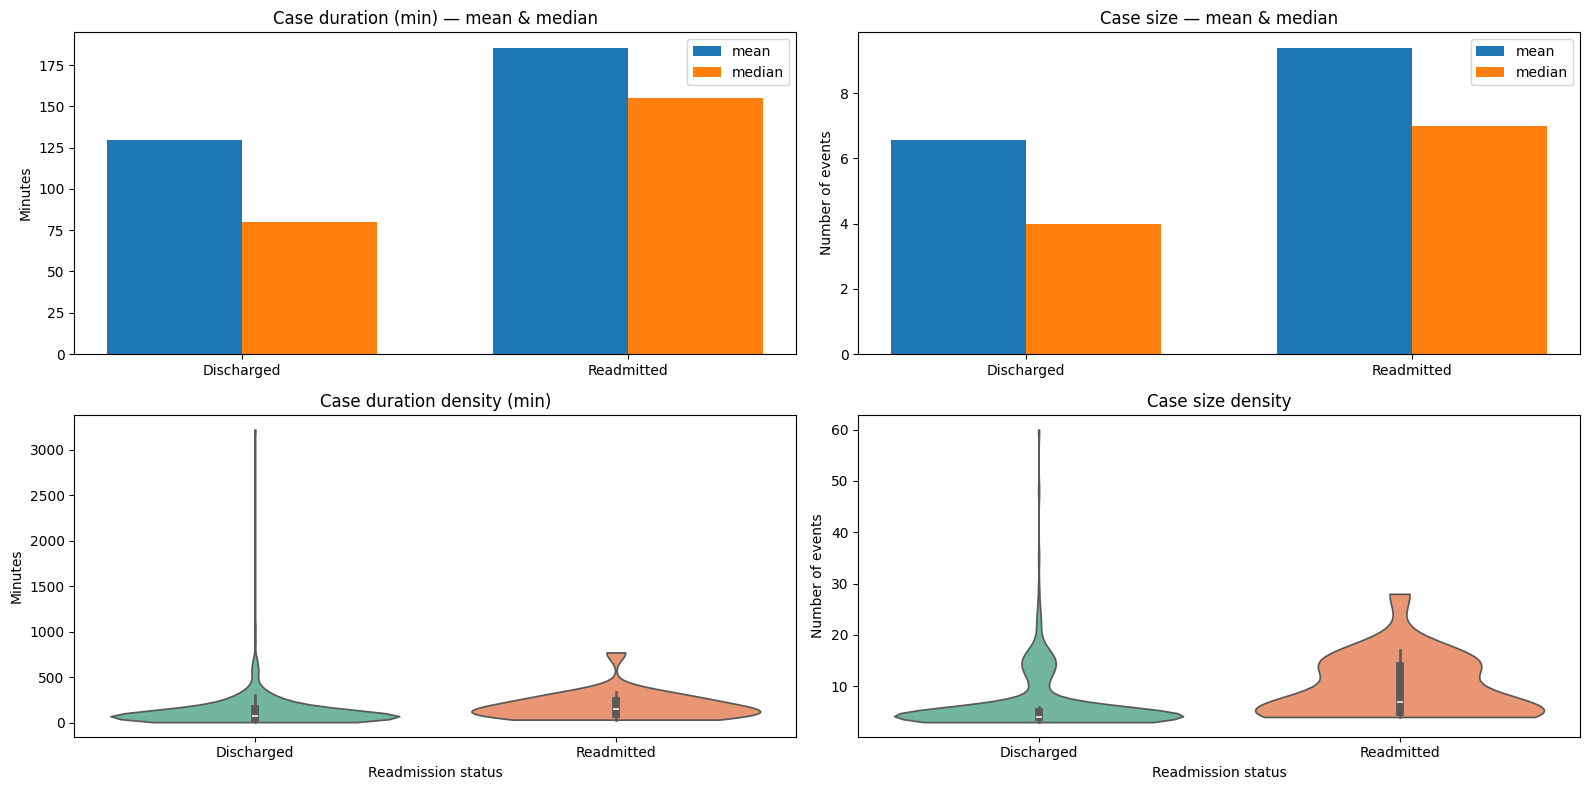

In [87]:
# Plot mean and median for duration and case size per segment
dur_mean = [kpi_discharged["duration_min"].mean(), kpi_readmitted["duration_min"].mean()]
dur_med = [kpi_discharged["duration_min"].median(), kpi_readmitted["duration_min"].median()]

size_mean = [kpi_discharged["case_size"].mean(), kpi_readmitted["case_size"].mean()]
size_med = [kpi_discharged["case_size"].median(), kpi_readmitted["case_size"].median()]

kpi_discharged_plot = kpi_discharged.copy()
kpi_discharged_plot['Readmission status'] = 'Discharged'

kpi_readmitted_plot = kpi_readmitted.copy()
kpi_readmitted_plot['Readmission status'] = 'Readmitted'

combined_kpis = pd.concat([kpi_discharged_plot, kpi_readmitted_plot])

labels = ["Discharged", "Readmitted"]
x = [0, 1]
width = 0.35

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))

# Duration plot
ax1.bar([xi - width / 2 for xi in x], dur_mean, width, label="mean")
ax1.bar([xi + width / 2 for xi in x], dur_med, width, label="median")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Case duration (min) — mean & median")
ax1.set_ylabel("Minutes")
ax1.legend()

# Case size plot
ax2.bar([xi - width / 2 for xi in x], size_mean, width, label="mean")
ax2.bar([xi + width / 2 for xi in x], size_med, width, label="median")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title("Case size — mean & median")
ax2.set_ylabel("Number of events")
ax2.legend()

# Duration plot
sns.violinplot(data=combined_kpis, x='Readmission status', y='duration_min', ax=ax3, palette='Set2', cut=0)
ax3.set_title("Case duration density (min)")
ax3.set_ylabel("Minutes")

# Case size plot
sns.violinplot(data=combined_kpis, x='Readmission status', y='case_size', ax=ax4, palette='Set2', cut=0)
ax4.set_title("Case size density")
ax4.set_ylabel("Number of events")

plt.tight_layout()
plt.show()

In [88]:
# Test KPIs between segments by Retorno (discharge)
print("\n=== Statistical analysis between discharged and readmitted cases ===\n")

kpis_to_test = ["duration_min", "case_size"]
for kpi in kpis_to_test:
    data_discharged = kpi_discharged[kpi].dropna()
    data_readmitted = kpi_readmitted[kpi].dropna()

    print(f"--- KPI: {kpi} (Sample sizes: discharged={len(data_discharged)}, readmitted={len(data_readmitted)}) ---")
    
    # Normality test (Shapiro-Wilk)
    _, p_shapiro_discharged = stats.shapiro(data_discharged)
    _, p_shapiro_readmitted = stats.shapiro(data_readmitted)
    
    is_normal_discharged = p_shapiro_discharged > 0.05
    is_normal_readmitted = p_shapiro_readmitted > 0.05
    
    print(f"Normality of segment discharged (Shapiro p-value): {p_shapiro_discharged:.4f} -> {'Normal' if is_normal_discharged else 'Non-normal'}")
    print(f"Normality of segment readmitted (Shapiro p-value): {p_shapiro_readmitted:.4f} -> {'Normal' if is_normal_readmitted else 'Non-normal'}")
    
    # Select test based on normality
    if is_normal_discharged and is_normal_readmitted:
        print("Each sample are normal, we use T-test.")
        # equal_var=False applies Welch's t-test, which is more robust when variances are unequal
        res_test = stats.ttest_ind(data_discharged, data_readmitted, equal_var=False) 
        test_name = "T-test"
    else:
        print("At least one sample is not normal. Performing Mann-Whitney U test.")
        res_test = stats.mannwhitneyu(data_discharged, data_readmitted, alternative='two-sided')
        test_name = "Mann-Whitney U"

    p_val = float(res_test.pvalue)

    print(f"Risultato {test_name} p-value: {p_val:.4f}")
    if p_val < 0.05:
        print(f"✅ There is a statistically significant difference between discharged and readmitted cases for '{kpi}'.\n")
    else:
        print(f"❌ There is NOT a statistically significant difference between discharged and readmitted cases for '{kpi}'.\n")


=== Statistical analysis between discharged and readmitted cases ===

--- KPI: duration_min (Sample sizes: discharged=411, readmitted=25) ---
Normality of segment discharged (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment readmitted (Shapiro p-value): 0.0001 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0021
✅ There is a statistically significant difference between discharged and readmitted cases for 'duration_min'.

--- KPI: case_size (Sample sizes: discharged=411, readmitted=25) ---
Normality of segment discharged (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment readmitted (Shapiro p-value): 0.0004 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0000
✅ There is a statistically significant difference between discharged and readmitted cases for 'case_size'.



Conclusion: There are a significant difference for case duration and case size between `discharged` and `readmitted` segment.
- case size: discharged[avg: 129.394161, median: 80.000000] readmitted[avg: 185.600000, median: 155.000000]
- case duration: discharged[avg: 6.564477, median: 4.000000] readmitted[avg: 9.400000, median: 7.000000]
- rework: discharged[avg: 1.788321, median: 0.000000] readmitted[avg: 3.760000, median: 1.000000]

### Readmissions and disease correlation

In [89]:
# Aggregate at case level to get one row per case with discharge_status and disease
corr_df = df.groupby("case:concept:name").agg(
    disease=("disease", "first"),
    readmission_status=("readmission_status", "first")
).reset_index()

corr_df["readmitted"] = (corr_df["readmission_status"] != "Sem retorno").astype(int)

corr_df.head()

,case:concept:name,disease,readmission_status,readmitted
0,5446538,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
1,5446540,R07.3 Outr dor toracica,Sem retorno,0
2,5446761,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
3,5446799,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
4,5446806,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0


In [90]:
# Crosstab for diseasea and readmission_status 
ct = pd.crosstab(corr_df["disease"], corr_df["readmission_status"])

ct 

readmission_status,Retorno em menos 24h,Retorno entre 24h e 48h,Retorno entre 48h e 72h,Sem retorno
disease,,,,
I64 Acid vasc cerebr NE como hemorrag isquemico,0,0,0,1
J10.1 Influenz c/out manif resp dev vir infl ident,0,0,0,1
J11.1 Influenza c/out manif resp dev virus n ident,4,6,4,335
J12.9 Pneumonia viral NE,0,0,0,3
N23 Colica nefretica NE,6,2,1,38
R07.3 Outr dor toracica,0,0,0,5
R07.4 Dor toracica NE,1,0,1,28


In [91]:
# Normalize to get proportions per disease
ct_norm = pd.crosstab(
    corr_df["disease"],
    corr_df["readmission_status"],
    normalize="index"
)

ct_norm

readmission_status,Retorno em menos 24h,Retorno entre 24h e 48h,Retorno entre 48h e 72h,Sem retorno
disease,,,,
I64 Acid vasc cerebr NE como hemorrag isquemico,0.000000,0.000000,0.000000,1.000000
J10.1 Influenz c/out manif resp dev vir infl ident,0.000000,0.000000,0.000000,1.000000
J11.1 Influenza c/out manif resp dev virus n ident,0.011461,0.017192,0.011461,0.959885
J12.9 Pneumonia viral NE,0.000000,0.000000,0.000000,1.000000
N23 Colica nefretica NE,0.127660,0.042553,0.021277,0.808511
R07.3 Outr dor toracica,0.000000,0.000000,0.000000,1.000000
R07.4 Dor toracica NE,0.033333,0.000000,0.033333,0.933333


C:\Users\milan\AppData\Local\Temp\ipykernel_19984\3307879246.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1600x800 with 0 Axes>

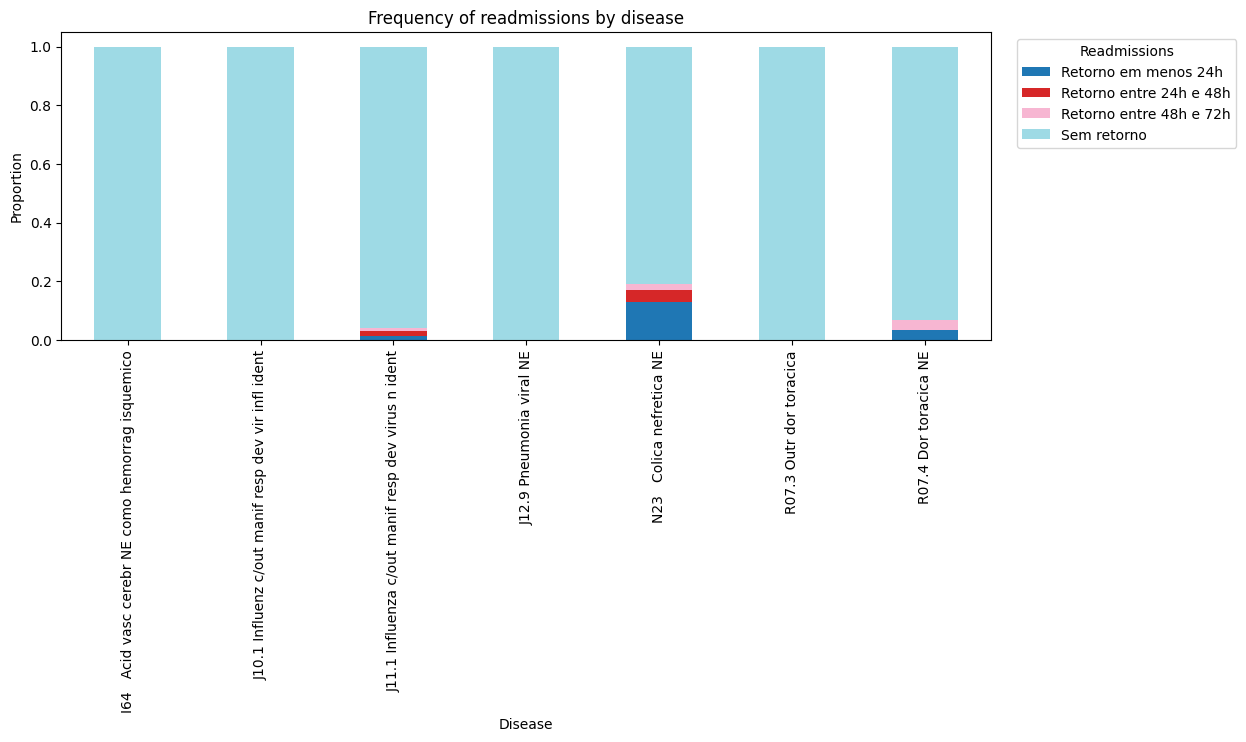

C:\Users\milan\AppData\Local\Temp\ipykernel_19984\3307879246.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=readmit_rate.values, y=readmit_rate.index, palette="magma")


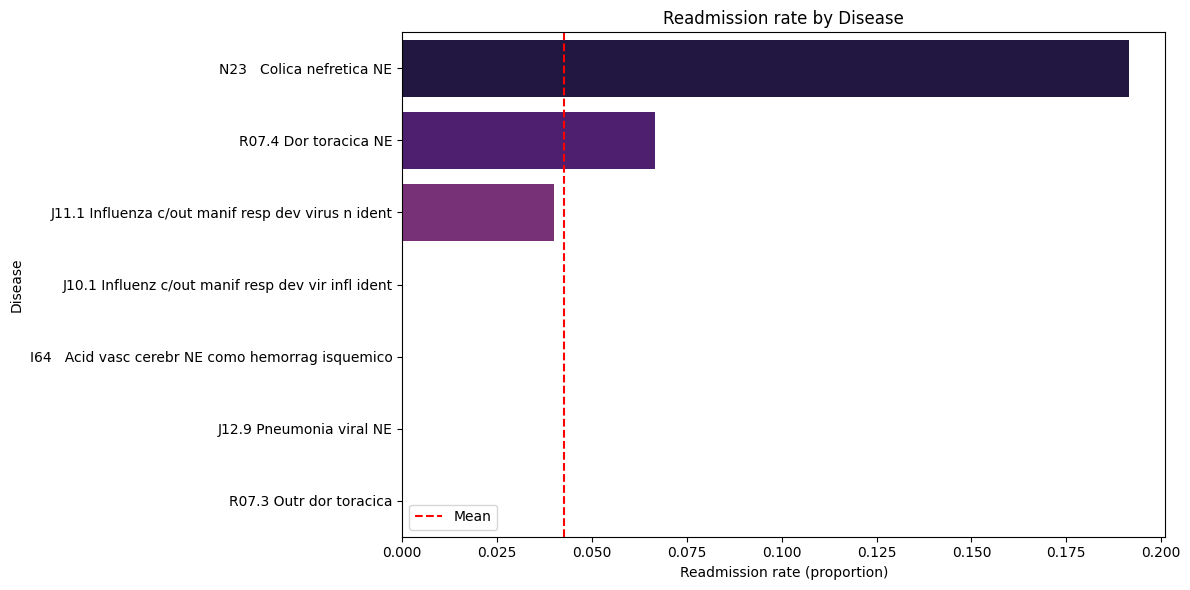

In [92]:
# Plot stacked bar: frequency of Retorno by disease
plt.figure(figsize=(16, 8))
ct_norm.plot(kind="bar", stacked=True, colormap="tab20", figsize=(12, 4))
plt.title("Frequency of readmissions by disease")
plt.ylabel("Proportion")
plt.xlabel("Disease")
plt.legend(title="Readmissions", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot readmission rate per disease
readmit_rate = corr_df.groupby("disease")["readmitted"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=readmit_rate.values, y=readmit_rate.index, palette="magma")
plt.axvline(readmit_rate.mean(), linestyle="--", color="red", label="Mean")
plt.xlabel("Readmission rate (proportion)")
plt.ylabel("Disease")
plt.title("Readmission rate by Disease")
plt.tight_layout()
plt.legend()
plt.show()

In [93]:
# Chi-squared test of independence between disease and readmission status on the complete contingency table
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-squared test: chi2={chi2:.2f}, p-value={p:.4f}, dof={dof}")

# Chi-squared test is valid if expected frequencies are all > 5
if (expected <= 5).sum() == 0:
    if p < 0.05:
        print("✅ There is a statistically significant association between disease and discharge status (readmission).")
    else:    
        print("❌ There is NOT a statistically significant association between disease and discharge status (readmission).")
else:
    print("⚠️ Some expected frequencies are not greater than 5, chi-squared test may not be valid.")

Chi-squared test: chi2=27.10, p-value=0.0771, dof=18
⚠️ Some expected frequencies are not greater than 5, chi-squared test may not be valid.


In [94]:
# For each disease, test of independence regarding readmission status vs all other diseases combined
# Fisher's exact test to calculates the exact probability of observing the data given the null hypothesis 
# of independence, without relying on large-sample approximations like previous Chi-squared test. 
# Since we are analyzing readmission rates for specific diseases, some diseases may have low 
# counts, making Fisher's exact test a better choice to assess the association between disease 
# and readmission status.
res = []
for disease, group in corr_df.groupby("disease"):
    others = corr_df[corr_df["disease"] != disease]

    a = group["readmitted"].sum()   # disease & readmitted
    b = len(group) - a              # disease & not readmitted
    c = others["readmitted"].sum()  # others & readmitted
    d = len(others) - c             # others & not readmitted

    # Avoid division by zero and invalid contingency tables for fisher-exact test
    try:
        odds_ratio, p_fisher = stats.fisher_exact([[a, b], [c, d]])
    except:
        odds_ratio, p_fisher = np.nan, np.nan

    res.append({
        "disease": disease,
        "count": len(group),
        "readmit_rate": a / (a + b) if (a + b) else np.nan,
        "odds_ratio": odds_ratio,
        "p_fisher": p_fisher
    })

res = pd.DataFrame(res).sort_values("p_fisher").reset_index(drop=True)

# Adjust p-values for multiple testing using Holm correction to reduce the chances of 
# false positives when performing multiple comparisons.
res["p_adj"] = multipletests(res["p_fisher"], method="holm")[1]


# Significant associations of diseases and readmission where p-value < 0.05
sig = res[res["p_adj"] < 0.05]
print(f"Significant associations between disease and readmission status (after Holm correction): {len(sig)}")
display(sig)

Significant associations between disease and readmission status (after Holm correction): 2


,disease,count,readmit_rate,odds_ratio,p_fisher,p_adj
0,N23 Colica nefretica NE,47,0.191489,5.521382,0.000501,0.003506
1,J11.1 Influenza c/out manif resp dev virus n i...,349,0.040115,0.288738,0.004221,0.025326


Conclusion: we have found a significant correlation between `N23   Colica nefretica NE` and `J11.1 Influenza c/out manif resp dev virus n ident` diseases and readmission compared to the others diseases:
- `N23   Colica nefretica NE`: has an odds ratio of 5.521382 (> 1), who has this disease returns 5.5 times more than normal
- `J11.1 Influenza c/out manif resp dev virus n ident`: has an odds ratio of 0.288738 (< 1), who has this disease returns 0.288738 times less than normal

### Resource segmentation analysis

C:\Users\milan\AppData\Local\Temp\ipykernel_19984\2771559959.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phys_counts.values, y=phys_counts.index, palette="viridis")


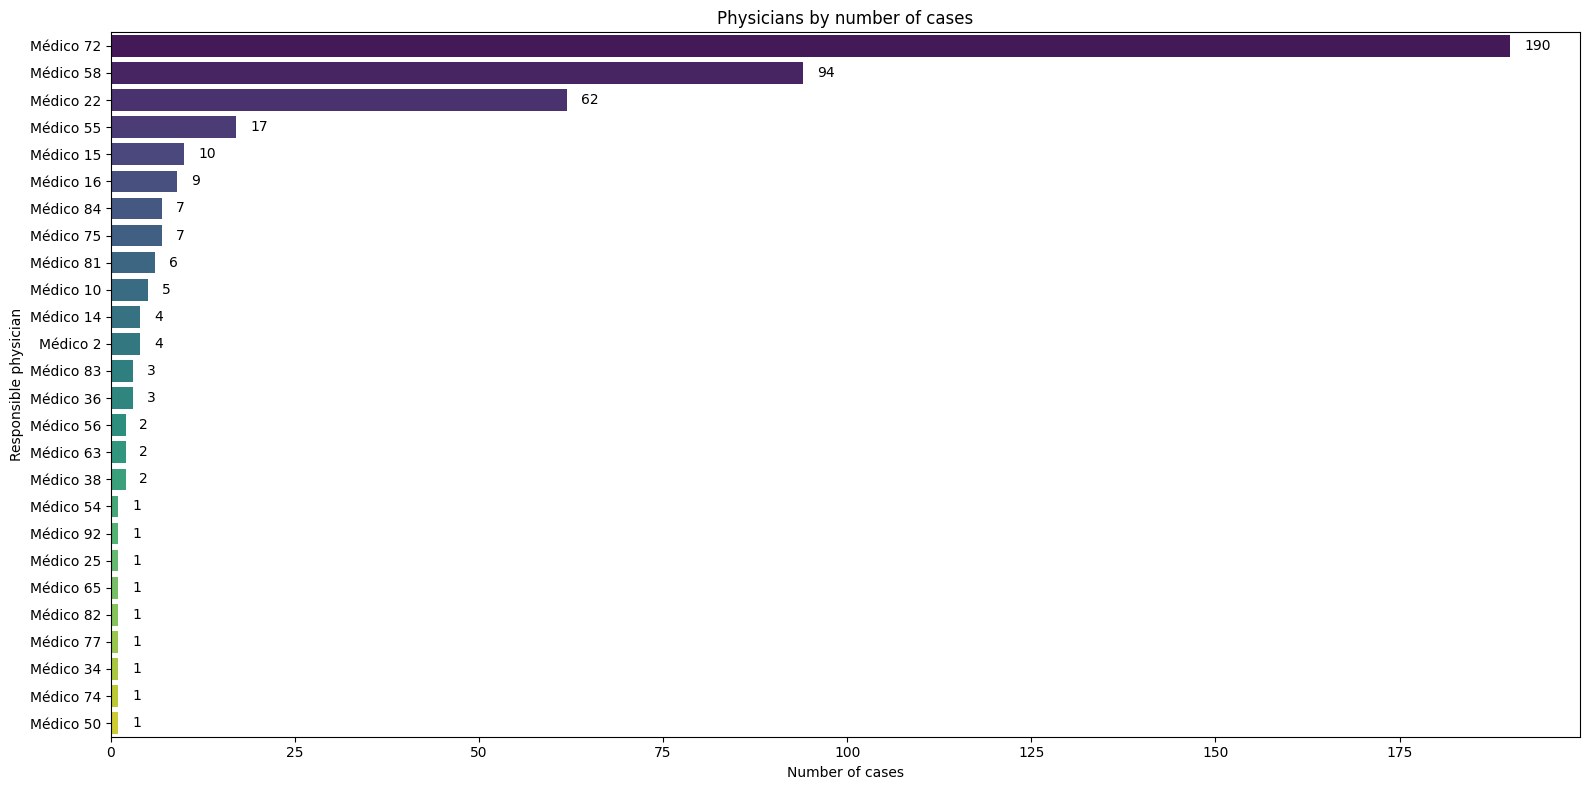

In [95]:
# Physician distribution: number of cases per physician (top 20)
phys_counts = df.groupby("case:concept:name")["responsible_physician"].first().value_counts()

plt.figure(figsize=(16, 8))
sns.barplot(x=phys_counts.values, y=phys_counts.index, palette="viridis")
plt.xlabel("Number of cases")
plt.ylabel("Responsible physician")
plt.title(f"Physicians by number of cases")
for i, v in enumerate(phys_counts.values):
    plt.text(v + max(phys_counts.values) * 0.01, i, f"{v}", va="center")
plt.tight_layout()
plt.show()

In [96]:
# Compute case KPIs for each physician
physician_kpis = df.groupby("responsible_physician").apply(compute_case_kpis) 

# Calculate case number and total duration per physician
physician_work = ( 
    physician_kpis.groupby(level=0).agg( 
        num_cases=("duration_min", "count"), 
        total_duration=("duration_min", "sum")
    ) 
    .sort_values("num_cases", ascending=False) 
).reset_index()

physician_work["coverage"] = physician_work["num_cases"] / physician_work["num_cases"].sum() * 100

print("Top 3 physicians cover {:.2f}% of cases.".format(physician_work["coverage"].head(3).sum()))

physician_work

Top 3 physicians cover 79.36% of cases.


,responsible_physician,num_cases,total_duration,coverage
0,Médico 72,190,19502.0,43.577982
1,Médico 58,94,9499.0,21.559633
2,Médico 22,62,6447.0,14.220183
3,Médico 55,17,3244.0,3.899083
4,Médico 15,10,2338.0,2.293578
5,Médico 16,9,4048.0,2.064220
6,Médico 75,7,816.0,1.605505
7,Médico 84,7,1211.0,1.605505
8,Médico 81,6,2163.0,1.376147
9,Médico 10,5,1188.0,1.146789


In [97]:

# Calculate a normalized workload index (cases + total duration) to identify physicians with high workload
physician_work["workload_index"] = (
    physician_work["num_cases"] / physician_work["num_cases"].mean() + 
    physician_work["total_duration"] / physician_work["total_duration"].mean()
)

physician_work

,responsible_physician,num_cases,total_duration,coverage,workload_index
0,Médico 72,190,19502.0,43.577982,20.099615
1,Médico 58,94,9499.0,21.559633,9.876859
2,Médico 22,62,6447.0,14.220183,6.596229
3,Médico 55,17,3244.0,3.899083,2.472470
4,Médico 15,10,2338.0,2.293578,1.647644
5,Médico 16,9,4048.0,2.064220,2.356936
6,Médico 75,7,816.0,1.605505,0.784357
7,Médico 84,7,1211.0,1.605505,0.961974
8,Médico 81,6,2163.0,1.376147,1.330421
9,Médico 10,5,1188.0,1.146789,0.832366


In [98]:
# Calculate Gini coefficient for workload distribution among physicians
gini_workload = Gini(physician_work["workload_index"].values)

if gini_workload.g < 0.3:
    print("✅ The workload distribution among physicians is relatively equitable.")
elif gini_workload.g < 0.5:
    print("⚠️ The workload distribution among physicians shows moderate inequality.")
else:
    print("❌ The workload distribution among physicians is highly unequal, with some physicians having a much higher workload than others.")

❌ The workload distribution among physicians is highly unequal, with some physicians having a much higher workload than others.


In [99]:
# Identify physicians with workload index above mean + 1 std as potentially overburdened
mean_workload = physician_work["workload_index"].mean()
std_workload = physician_work["workload_index"].std()

high_workload_phys = physician_work[physician_work["workload_index"] > mean_workload + std_workload]
print(f"Physicians with workload index above mean + 1 std: {len(high_workload_phys)}")
display(high_workload_phys)

Physicians with workload index above mean + 1 std: 3


,responsible_physician,num_cases,total_duration,coverage,workload_index
0,Médico 72,190,19502.0,43.577982,20.099615
1,Médico 58,94,9499.0,21.559633,9.876859
2,Médico 22,62,6447.0,14.220183,6.596229


Conclusion:
- Top 3 physician cover about 80% of cases
- Médico 72	cover 43.5% of total cases
- Physician "Médico 72", "Médico 58" and "Médico 22" (top 3) have a significant higher workload than others.

### Disease segmentation analysis

In [100]:
disease_kpis = df.groupby("disease").apply(compute_case_kpis).reset_index()

disease_stats = ( 
    disease_kpis.groupby("disease").agg( 
        num_cases=("duration_min", "count"),
        mean_duration=("duration_min", "mean"),
        median_duration=("duration_min", "median"),
        mean_case_size=("case_size", "mean"),
        median_case_size=("case_size", "median"),
        mean_rework=("rework_count", "mean"),
        median_rework=("rework_count", "median")
    ) 
    .sort_values("num_cases", ascending=False) 
).reset_index()

disease_stats["coverage"] = disease_stats["num_cases"] / disease_stats["num_cases"].sum() * 100

print("Top 3 diseases cover {:.2f}% of cases.".format(disease_stats["coverage"].head(3).sum()))

disease_stats

Top 3 diseases cover 97.71% of cases.


,disease,num_cases,mean_duration,median_duration,mean_case_size,median_case_size,mean_rework,median_rework,coverage
0,J11.1 Influenza c/out manif resp dev virus n i...,349,111.839542,71.0,5.065903,4.0,0.661891,0.0,80.045872
1,N23 Colica nefretica NE,47,192.702128,170.0,15.404255,15.0,8.468085,8.0,10.779817
2,R07.4 Dor toracica NE,30,250.033333,145.5,12.433333,8.0,6.266667,2.0,6.880734
3,R07.3 Outr dor toracica,5,241.600000,149.0,5.800000,5.0,0.400000,0.0,1.146789
4,J12.9 Pneumonia viral NE,3,292.666667,132.0,9.333333,7.0,3.000000,0.0,0.688073
5,J10.1 Influenz c/out manif resp dev vir infl i...,1,90.000000,90.0,6.000000,6.0,1.000000,1.0,0.229358
6,I64 Acid vasc cerebr NE como hemorrag isquemico,1,55.000000,55.0,5.000000,5.0,0.000000,0.0,0.229358


In [101]:
kpis_to_test = ["duration_min", "case_size", "rework_count"]

for kpi in kpis_to_test:
    # List of groups: each group is an array of KPI values for a disease
    groups = [group[kpi].values for _, group in disease_kpis.groupby("disease")]
    
    stat, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis test for '{kpi}': H={stat:.3f}, p={p:.4e}")
    
    if p < 0.05:
        print(f"✅ There are significant differences between diseases for '{kpi}'.\n")
    else:
        print(f"❌ No significant differences between diseases for '{kpi}'.\n")

Kruskal-Wallis test for 'duration_min': H=61.614, p=2.1143e-11
✅ There are significant differences between diseases for 'duration_min'.

Kruskal-Wallis test for 'case_size': H=170.280, p=3.9238e-34
✅ There are significant differences between diseases for 'case_size'.

Kruskal-Wallis test for 'rework_count': H=193.096, p=5.5880e-39
✅ There are significant differences between diseases for 'rework_count'.



In [102]:
# Since we found significant differences in KPIs across diseases, we perform pairwise comparisons
# to identify which specific diseases diffe from the others for each KPI.
results = []
for kpi in kpis_to_test:
    for disease in disease_stats["disease"].unique():
        group_disease = disease_kpis[disease_kpis["disease"] == disease][kpi]
        group_others = disease_kpis[disease_kpis["disease"] != disease][kpi]
        
        stat, p = stats.mannwhitneyu(group_disease, group_others, alternative='two-sided')
        
        direction = "equal"
        if stat > len(group_disease) * len(group_others) / 2:
            direction = "higher"
        elif stat < len(group_disease) * len(group_others) / 2:
            direction = "lower" 

        results.append({
            "disease": disease,
            "kpi": kpi,
            "p_val": p,
            "direction": direction
        })
    
results_df = pd.DataFrame(results)

# Adjust p-values for multiple testing using Holm correction to reduce the chances of false positives when performing multiple comparisons.
results_df["p_adj"] = multipletests(results_df["p_val"], method="holm")[1]

for kpi in kpis_to_test:
    sig_kpi = results_df[(results_df["kpi"] == kpi) & (results_df["p_adj"] < 0.05)]
    print(f"Significant differences for '{kpi}': {len(sig_kpi)} diseases")
    display(sig_kpi.sort_values("p_adj", ascending=False))

Significant differences for 'duration_min': 3 diseases


,disease,kpi,p_val,direction,p_adj
2,R07.4 Dor toracica NE,duration_min,3.043577e-03,higher,3.956649e-02
1,N23 Colica nefretica NE,duration_min,6.971598e-11,higher,1.115456e-09
0,J11.1 Influenza c/out manif resp dev virus n i...,duration_min,5.489238e-14,lower,9.331704e-13


Significant differences for 'case_size': 3 diseases


,disease,kpi,p_val,direction,p_adj
9,R07.4 Dor toracica NE,case_size,1.128599e-06,higher,1.692898e-05
8,N23 Colica nefretica NE,case_size,4.329977e-28,higher,7.793959e-27
7,J11.1 Influenza c/out manif resp dev virus n i...,case_size,7.254853e-37,lower,1.450971e-35


Significant differences for 'rework_count': 3 diseases


,disease,kpi,p_val,direction,p_adj
16,R07.4 Dor toracica NE,rework_count,6.458187e-05,higher,9.041462e-04
14,J11.1 Influenza c/out manif resp dev virus n i...,rework_count,6.189978e-36,lower,1.176096e-34
15,N23 Colica nefretica NE,rework_count,4.091543e-37,higher,8.592239e-36


Conclusion: 
- Top 3 disease cover almast all the cases (97.71%)
- `J11.1 Influenza c/out manif resp dev virus n i...` cover 80% of cases
- There are significant differences between diseases for case duration, case size and rework activities
- `R07.4 Dor toracica NE` and `N23   Colica nefretica NE` have significant higher case duration, case size and rework activities compared to the others
- `J11.1 Influenza c/out manif resp dev virus n i...` have significant lower case duration, case size and rework activities compared to the others